# Analysis & Plotting Monomeric Intra XLs 

### Setup

In [55]:
import pandas as pd
import numpy as np
from pathlib import Path
from Bio.PDB import MMCIFParser
import warnings
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path(__file__).resolve().parents[1]))
from config import REPO_ROOT, PROCESSED_DATA_DIR

In [56]:
monomer_df = pd.read_csv(PROCESSED_DATA_DIR / '00_naive_monomer_intra_xl_calculations.csv')

null_monomer_df = pd.read_csv(PROCESSED_DATA_DIR / '01_naive_monomer_null_intra_xl_calculations.csv')

print(monomer_df.columns)
display(monomer_df.head())
display(null_monomer_df.head())
print(monomer_df.shape)

Index(['protein_id', 'Crosslink Position A', 'Crosslink Position B',
       'Crosslinked Residue A', 'Crosslinked Residue B', 'model_0_pae',
       'model_0_ptm', 'model_0_distance', 'model_1_pae', 'model_1_ptm',
       'model_1_distance', 'model_2_pae', 'model_2_ptm', 'model_2_distance',
       'model_3_pae', 'model_3_ptm', 'model_3_distance', 'model_4_pae',
       'model_4_ptm', 'model_4_distance', 'distance_mean', 'distance_std',
       'distance_min', 'distance_max', 'pae_mean', 'ptm_mean',
       'pae_best_model_idx', 'pae_best_model', 'pae_best_model_distance',
       'ptm_pae_best_model', 'model_0_xl_site_pae',
       'model_0_xl_window_pae_mean', 'model_0_xl_window_pae_median',
       'model_1_xl_site_pae', 'model_1_xl_window_pae_mean',
       'model_1_xl_window_pae_median', 'model_2_xl_site_pae',
       'model_2_xl_window_pae_mean', 'model_2_xl_window_pae_median',
       'model_3_xl_site_pae', 'model_3_xl_window_pae_mean',
       'model_3_xl_window_pae_median', 'model_4_xl_sit

,protein_id,Crosslink Position A,Crosslink Position B,Crosslinked Residue A,Crosslinked Residue B,model_0_pae,model_0_ptm,model_0_distance,model_1_pae,model_1_ptm,...,xl_site_pae_mean,xl_window_pae_mean_mean,xl_window_pae_median_mean,xl_site_pae_best_model_idx,xl_site_pae_best_model,xl_site_pae_best_model_distance,xl_window_pae_mean_best_model_idx,xl_window_pae_mean_best_model,xl_window_pae_mean_best_model_distance,ptm_xl_window_pae_mean_best_model
0,TGRH88_050980,751.0,736.0,K,K,18.570929,0.622231,14.846814,19.112965,0.599051,...,21.957796,21.466352,21.882094,4.0,20.516304,22.076820,4.0,19.859512,22.076820,0.620942
1,TGRH88_050980,714.0,751.0,K,K,18.570929,0.622231,52.560902,19.112965,0.599051,...,28.124450,27.825587,27.799215,4.0,27.711065,50.040867,4.0,27.418875,50.040867,0.620942
2,TGRH88_050980,560.0,736.0,K,K,18.570929,0.622231,12.298800,19.112965,0.599051,...,25.539624,25.823130,25.722409,3.0,25.239773,18.271023,0.0,25.391079,12.298800,0.622231
3,TGRH88_050980,714.0,736.0,K,K,18.570929,0.622231,41.194839,19.112965,0.599051,...,23.447815,23.020553,22.936749,1.0,23.045200,12.632446,4.0,22.617210,35.011612,0.620942
4,TGRH88_050980,252.0,579.0,K,K,18.570929,0.622231,12.713394,19.112965,0.599051,...,16.338627,16.738572,17.144842,0.0,16.139303,12.713394,2.0,16.442511,12.897325,0.609962


,protein_id,Crosslink Position A,Crosslink Position B,Crosslinked Residue A,Crosslinked Residue B,model_0_pae,model_0_ptm,model_0_distance,model_1_pae,model_1_ptm,...,xl_site_pae_mean,xl_window_pae_mean_mean,xl_window_pae_median_mean,xl_site_pae_best_model_idx,xl_site_pae_best_model,xl_site_pae_best_model_distance,xl_window_pae_mean_best_model_idx,xl_window_pae_mean_best_model,xl_window_pae_mean_best_model_distance,ptm_xl_window_pae_mean_best_model
0,TGRH88_050980,468.0,562.0,K,K,18.570929,0.622231,45.998306,19.112965,0.599051,...,25.140812,25.702549,25.691687,0.0,24.492491,45.998306,0.0,25.330616,45.998306,0.622231
1,TGRH88_050980,114.0,763.0,K,K,18.570929,0.622231,45.901451,19.112965,0.599051,...,26.251484,26.214279,26.393207,0.0,26.034061,45.901451,0.0,26.051805,45.901451,0.622231
2,TGRH88_050980,53.0,565.0,K,K,18.570929,0.622231,32.935585,19.112965,0.599051,...,16.419967,15.818317,15.565625,2.0,15.938216,33.280853,2.0,15.595157,33.280853,0.609962
3,TGRH88_050980,579.0,716.0,K,K,18.570929,0.622231,48.921246,19.112965,0.599051,...,23.289330,22.992577,23.179594,4.0,22.686047,49.343609,4.0,22.417212,49.343609,0.620942
4,TGRH88_050980,252.0,502.0,K,K,18.570929,0.622231,29.662766,19.112965,0.599051,...,12.932212,12.338536,12.416772,0.0,12.782520,29.662766,0.0,12.169620,29.662766,0.622231


(12069, 55)


### Monomer frequency plotted by pTM & PAE

In [57]:
# Unique crosslinks: one row per (protein, positions A/B, residues A/B)
xl_key_cols = [
    "protein_id",
    "Crosslink Position A",
    "Crosslink Position B",
    "Crosslinked Residue A",
    "Crosslinked Residue B",
]
unique_xl_df = monomer_df.drop_duplicates(subset=xl_key_cols).copy()

# Per protein: keep the row with the lowest xl_window_pae_mean_best_model
unique_mono_df = (
    monomer_df.sort_values("xl_window_pae_mean_best_model", na_position="last")
    .groupby("protein_id", as_index=False)
    .first()
)
print(unique_mono_df.shape)

(1495, 55)


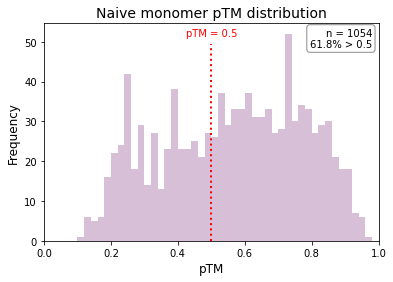

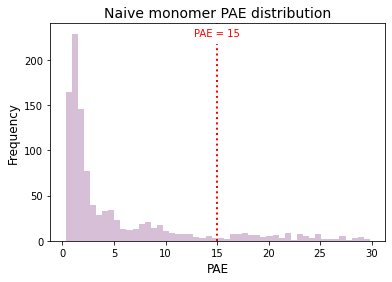

In [86]:
# Plot frequency by pTM (pTM of the same model with xl_window_pae_mean_best_model)
values = unique_mono_df['ptm_xl_window_pae_mean_best_model'].dropna()
n = len(values)
percent_above_05 = (values > 0.5).sum() / n * 100

plt.hist(
    values,
    bins=50,
    color='thistle',
    range=(0.0, 1.0)
)
plt.axvline(x=0.5, linestyle='dotted', linewidth=2, color='red')
# Add centered "pTM = 0.5" label above the red line
ylim = plt.ylim()
ypos = ylim[1] * 0.93  # 93% up the y-axis
plt.text(
    0.5, ypos, 'pTM = 0.5', color='red', ha='center', va='bottom', fontsize=10, backgroundcolor='white'
)
plt.xlabel('pTM', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Naive monomer pTM distribution', fontsize=14)
plt.xlim(0.0, 1.0)  # Ensure x axis covers full range

# Add n and percentage above 0.5 as a box in the plot
box_text = f"n = {n}\n{percent_above_05:.1f}% > 0.5"
plt.gca().text(
    0.98, 0.98, box_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3', alpha=0.9)
)

plt.show()

#plot frequency by PAE (PAE of the same model with xl_window_pae_mean_best_model)
plt.hist(unique_mono_df['xl_window_pae_mean_best_model'], bins=50, color='thistle')
plt.axvline(x=15, linestyle='dotted', linewidth=2, color='red')
# Add centered "pTM = 0.5" label above the red line
ylim = plt.ylim()
ypos = ylim[1] * 0.93  # 93% up the y-axis
plt.text(
    15, ypos, 'PAE = 15', color='red', ha='center', va='bottom', fontsize=10, backgroundcolor='white'
)
plt.xlabel('PAE', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Naive monomer PAE distribution', fontsize=14)
plt.show()

### Plot 1: Crosslink-centric plot of monomeric PAE and intraprotein distance agreement:



In [59]:
# Unique crosslinks: one row per (protein, positions A/B, residues A/B)
xl_key_cols = [
    "protein_id",
    "Crosslink Position A",
    "Crosslink Position B",
    "Crosslinked Residue A",
    "Crosslinked Residue B",
]
unique_xl_df = monomer_df.drop_duplicates(subset=xl_key_cols).copy()

# Per protein: keep the row with the lowest min_xl_window_pae_mean_value
unique_mono_df = (
    monomer_df.sort_values("xl_window_pae_mean_best_model", na_position="last")
    .groupby("protein_id", as_index=False)
    .first()
)

model_dist_cols = [f"model_{i}_distance" for i in range(5)]
n_models = unique_xl_df[model_dist_cols].notna().sum(axis=1)
unique_xl_df["frac_models_lt_35A"] = (
    (unique_xl_df[model_dist_cols] < 35.0).sum(axis=1) / n_models.replace(0, np.nan)
)

pae_bin_labels  = ["<15",">15"]
pae_bins        = [0, 15, np.inf]
unique_xl_df["pae_mean_bin"] = pd.cut(
    unique_xl_df["xl_window_pae_mean_best_model"],
    bins=pae_bins,
    labels=pae_bin_labels,
    right=False,
    include_lowest=True,
)

n_models_mono = unique_mono_df[model_dist_cols].notna().sum(axis=1)
unique_mono_df["frac_models_lt_35A"] = (
    (unique_mono_df[model_dist_cols] < 35.0).sum(axis=1) / n_models_mono.replace(0, np.nan)
)
unique_mono_df["pae_mean_bin"] = pd.cut(
    unique_mono_df["xl_window_pae_mean_best_model"],
    bins=pae_bins,
    labels=pae_bin_labels,
    right=False,
    include_lowest=True,
)

unique_xl_df["n_models_satisfied"] = (
    unique_xl_df[model_dist_cols] < 35.0
).sum(axis=1).astype(int)
unique_mono_df["n_models_satisfied"] = (
    unique_mono_df[model_dist_cols] < 35.0
).sum(axis=1).astype(int)



/tmp/ipykernel_3548370/1771723131.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


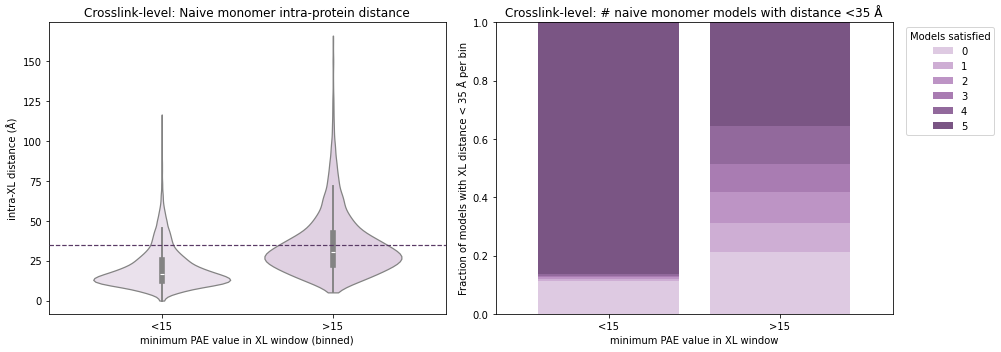

/tmp/ipykernel_3548370/1771723131.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


unique_xl_df: 12,069 rows
unique_mono_df: 1,495 rows (one per protein_id)


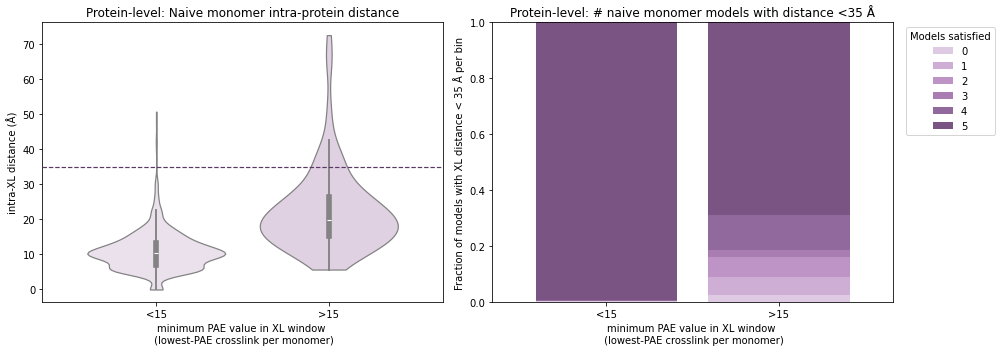

In [75]:
plot_xl = unique_xl_df.dropna(
    subset=["pae_mean_bin", "xl_window_pae_mean_best_model_distance"]
).copy()

BASE_PURPLE = "blend:#FFFFFF,#B586BE,#4B2E57"

_purples = sns.color_palette(BASE_PURPLE, 16)

purple_bins = _purples[2 : 2 + len(pae_bin_labels)]
purple_line = _purples[-2]

def purple_stack_colors(n):
    pal = sns.color_palette(BASE_PURPLE, max(n + 4, 8))
    return pal[2 : 2 + n]


fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

sns.violinplot(
    data=plot_xl,
    x="pae_mean_bin",
    y="xl_window_pae_mean_best_model_distance",
    order=pae_bin_labels,
    ax=axes[0],
    inner="box",
    cut=0,
    palette=purple_bins,
)
axes[0].axhline(35, color=purple_line, linestyle="--", linewidth=1.2, zorder=10)
axes[0].set_xlabel("minimum PAE value in XL window (binned)")
axes[0].set_ylabel("intra-XL distance (Å)")
axes[0].set_title("Crosslink-level: Naive monomer intra-protein distance")

plot_frac = unique_xl_df.dropna(
    subset=["pae_mean_bin", "frac_models_lt_35A", "n_models_satisfied"]
).copy()
# Violin/KDE is a poor fit: only 6 discrete outcomes (0–5 models satisfied)
n_sat_xl = np.arange(0, int(plot_frac["n_models_satisfied"].max()) + 1)
ct_xl = pd.crosstab(
    plot_frac["pae_mean_bin"], plot_frac["n_models_satisfied"], normalize="index"
)
ct_xl = ct_xl.reindex(pae_bin_labels, fill_value=0).reindex(columns=n_sat_xl, fill_value=0)
ct_xl.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    width=0.82,
    color=purple_stack_colors(len(n_sat_xl)),
    legend=True,
)
axes[1].set_xlabel("minimum PAE value in XL window")
axes[1].set_ylabel("Fraction of models with XL distance < 35 Å per bin")
axes[1].set_title(
    "Crosslink-level: # naive monomer models with distance <35 Å"
)
axes[1].set_ylim(0, 1)
axes[1].legend(title="Models satisfied", bbox_to_anchor=(1.02, 1), loc="upper left")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

plot_mono = unique_mono_df.dropna(
    subset=["pae_mean_bin", "xl_window_pae_mean_best_model_distance"]
).copy()

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5), sharex=True)

sns.violinplot(
    data=plot_mono,
    x="pae_mean_bin",
    y="xl_window_pae_mean_best_model_distance",
    order=pae_bin_labels,
    ax=axes2[0],
    inner="box",
    cut=0,
    palette=purple_bins,
)
axes2[0].axhline(35, color=purple_line, linestyle="--", linewidth=1.2, zorder=10)
axes2[0].set_xlabel("minimum PAE value in XL window \n (lowest-PAE crosslink per monomer)")
axes2[0].set_ylabel("intra-XL distance (Å)")
axes2[0].set_title(
    "Protein-level: Naive monomer intra-protein distance"
)

plot_mono_frac = unique_mono_df.dropna(
    subset=["pae_mean_bin", "frac_models_lt_35A", "n_models_satisfied"]
).copy()
n_sat_mono = np.arange(0, int(plot_mono_frac["n_models_satisfied"].max()) + 1)
ct_mono = pd.crosstab(
    plot_mono_frac["pae_mean_bin"],
    plot_mono_frac["n_models_satisfied"],
    normalize="index",
)
ct_mono = ct_mono.reindex(pae_bin_labels, fill_value=0).reindex(
    columns=n_sat_mono, fill_value=0
)
ct_mono.plot(
    kind="bar",
    stacked=True,
    ax=axes2[1],
    width=0.82,
    color=purple_stack_colors(len(n_sat_mono)),
    legend=True,
)
# axes2[1].set_xlabel("min_xl_window_pae_mean_value (binned)")
# axes2[1].set_ylabel("Fraction of proteins in bin")
# axes2[1].set_title(
#     "Protein-level: # models <35 Å on best XL (stacked, sums to 1 per bin)"
# )
axes2[1].set_xlabel("minimum PAE value in XL window \n (lowest-PAE crosslink per monomer)")
axes2[1].set_ylabel("Fraction of models with XL distance < 35 Å per bin")
axes2[1].set_title(
    "Protein-level: # naive monomer models with distance <35 Å"
)
axes2[1].set_ylim(0, 1)
axes2[1].legend(title="Models satisfied", bbox_to_anchor=(1.02, 1), loc="upper left")
axes2[1].tick_params(axis="x", rotation=0)

plt.tight_layout()





print(f"unique_xl_df: {len(unique_xl_df):,} rows")
print(f"unique_mono_df: {len(unique_mono_df):,} rows (one per protein_id)")

### Plots updated with null XL data

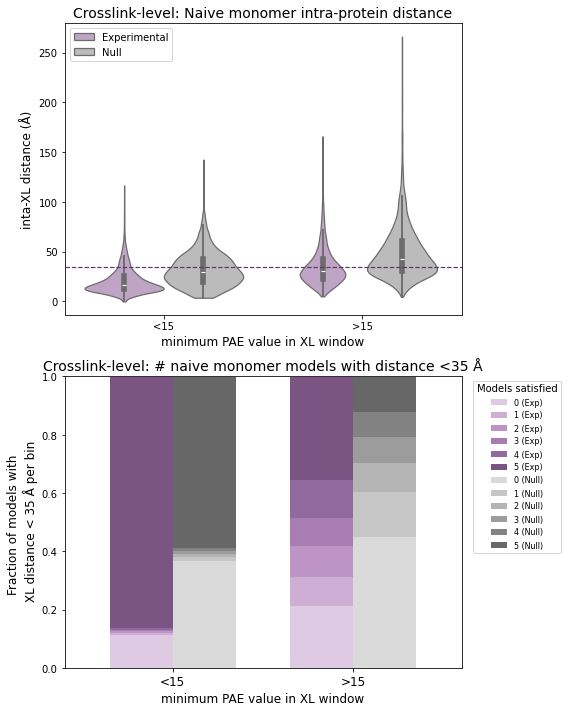

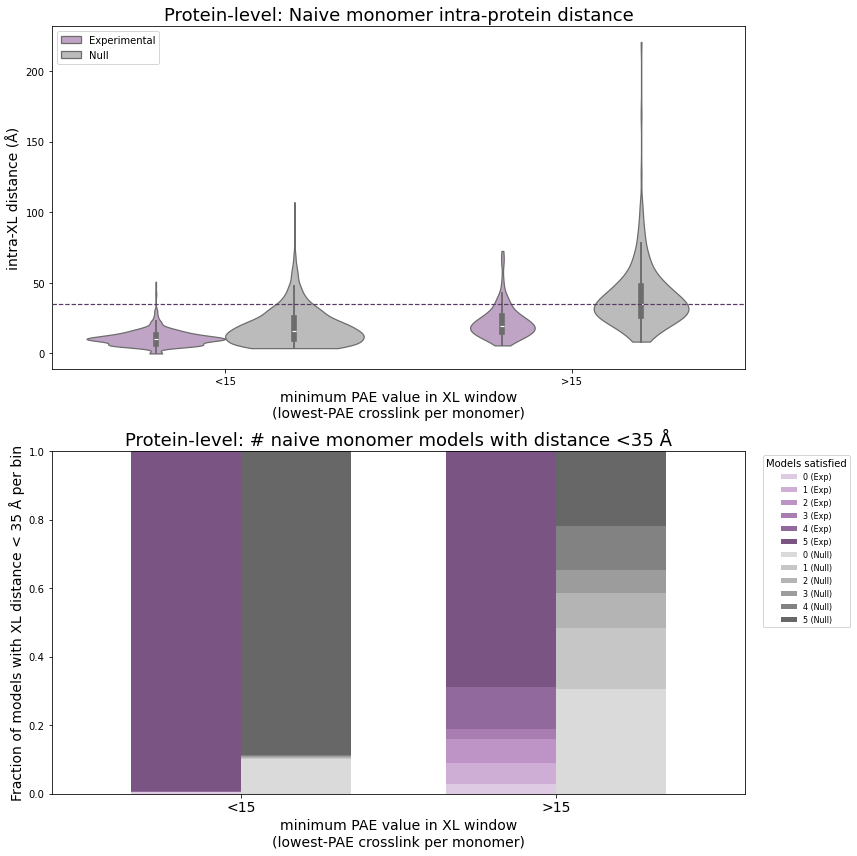

unique_xl_df:   12,069 rows  |  null_xl_df:   12,069 rows
unique_mono_df: 1,495 rows  |  null_mono_df: 1,495 rows


In [80]:
# ── Load and preprocess null data from a single CSV ───────────────────────────
null_df = null_monomer_df # adjust path as needed

# Same preprocessing as experimental ─────────────────────────────────────────
xl_key_cols = [
    "protein_id",
    "Crosslink Position A",
    "Crosslink Position B",
    "Crosslinked Residue A",
    "Crosslinked Residue B",
]
model_dist_cols = [f"model_{i}_distance" for i in range(5)]
# pae_bin_labels  = ["0-5", "5-10", "10-15", "15-20", "20-30", "30+"]
# pae_bins        = [0, 5, 10, 15, 20, 30, np.inf]
pae_bin_labels  = ["<15", ">15"]
pae_bins        = [0, 15, np.inf]

def preprocess(df):
    """Return (unique_xl_df, unique_mono_df) from a raw monomer-style dataframe."""
    # Unique crosslinks
    xl = df.drop_duplicates(subset=xl_key_cols).copy()

    # Per-protein: row with lowest xl_window_pae_mean_best_model
    mono = (
        df.sort_values("xl_window_pae_mean_best_model", na_position="last")
          .groupby("protein_id", as_index=False)
          .first()
    )

    for frame in (xl, mono):
        n_models = frame[model_dist_cols].notna().sum(axis=1)
        frame["frac_models_lt_35A"] = (
            (frame[model_dist_cols] < 35.0).sum(axis=1)
            / n_models.replace(0, np.nan)
        )
        frame["pae_mean_bin"] = pd.cut(
            frame["xl_window_pae_mean_best_model"],
            bins=pae_bins,
            labels=pae_bin_labels,
            right=False,
            include_lowest=True,
        )
        frame["n_models_satisfied"] = (
            (frame[model_dist_cols] < 35.0).sum(axis=1).astype(int)
        )

    return xl, mono

null_xl_df, null_mono_df = preprocess(null_df)

# ── Color palettes ─────────────────────────────────────────────────────────────
BASE_PURPLE = "blend:#FFFFFF,#B586BE,#4B2E57"
BASE_GRAY   = "blend:#FFFFFF,#AAAAAA,#333333"

_purples = sns.color_palette(BASE_PURPLE, 16)
_grays   = sns.color_palette(BASE_GRAY,   16)

purple_line = _purples[-2]

def make_palette(base, n):
    pal = sns.color_palette(base, max(n + 4, 8))
    return pal[2 : 2 + n]

# ── Helper: tag and concatenate exp + null ────────────────────────────────────
def combine(exp_df, null_df, cols):
    e = exp_df.dropna(subset=cols).copy(); e["source"] = "Experimental"
    n = null_df.dropna(subset=cols).copy(); n["source"] = "Null"
    return pd.concat([e, n], ignore_index=True)

# ── Helper: crosstab normalised by index ─────────────────────────────────────
def make_crosstab(df, bin_labels, n_sat):
    ct = pd.crosstab(df["pae_mean_bin"], df["n_models_satisfied"], normalize="index")
    return (
        ct.reindex(bin_labels, fill_value=0)
          .reindex(columns=n_sat, fill_value=0)
    )

DIST_COLS = ["pae_mean_bin", "xl_window_pae_mean_best_model_distance"]
FRAC_COLS = ["pae_mean_bin", "frac_models_lt_35A", "n_models_satisfied"]

from matplotlib.patches import Patch

# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE 1 — Crosslink-level
# ══════════════════════════════════════════════════════════════════════════════
plot_xl_both        = combine(unique_xl_df,   null_xl_df,   DIST_COLS)
plot_xl_frac_both   = combine(unique_xl_df,   null_xl_df,   FRAC_COLS)

fig, axes = plt.subplots(2, 1, figsize=(8,10))

# Left: side-by-side violins --------------------------------------------------
sns.violinplot(
    data=plot_xl_both,
    x="pae_mean_bin",
    y="xl_window_pae_mean_best_model_distance",
    hue="source",
    hue_order=["Experimental", "Null"],
    order=pae_bin_labels,
    ax=axes[0],
    inner="box",
    cut=0,
    palette={"Experimental": _purples[6], "Null": _grays[6]},
)
axes[0].axhline(35, color=purple_line, linestyle="--", linewidth=1.2, zorder=10)
axes[0].set_xlabel("minimum PAE value in XL window", fontsize=12)
axes[0].set_ylabel("inta-XL distance (Å)", fontsize=12)
axes[0].set_title("Crosslink-level: Naive monomer intra-protein distance", fontsize=14)
axes[0].legend(title=None, loc="upper left")  # <--- Remove legend title, move to plot upper left

# Right: side-by-side stacked bars --------------------------------------------
xl_frac_exp  = plot_xl_frac_both[plot_xl_frac_both["source"] == "Experimental"]
xl_frac_null = plot_xl_frac_both[plot_xl_frac_both["source"] == "Null"]

n_sat_xl      = np.arange(0, int(plot_xl_frac_both["n_models_satisfied"].max()) + 1)
ct_xl_exp     = make_crosstab(xl_frac_exp,  pae_bin_labels, n_sat_xl)
ct_xl_null    = make_crosstab(xl_frac_null, pae_bin_labels, n_sat_xl)
purple_cols   = make_palette(BASE_PURPLE, len(n_sat_xl))
gray_cols     = make_palette(BASE_GRAY,   len(n_sat_xl))

ct_xl_exp.plot( kind="bar", stacked=True, ax=axes[1], width=0.35,
                color=purple_cols, legend=False, position=1)
ct_xl_null.plot(kind="bar", stacked=True, ax=axes[1], width=0.35,
                color=gray_cols,   legend=False, position=0)

axes[1].legend(
    handles=(
        [Patch(facecolor=purple_cols[i], label=f"{i} (Exp)")  for i in n_sat_xl] +
        [Patch(facecolor=gray_cols[i],   label=f"{i} (Null)") for i in n_sat_xl]
    ),
    title="Models satisfied", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8,
)
axes[1].set_xticks(range(len(pae_bin_labels)))
axes[1].set_xticklabels(pae_bin_labels, rotation=0, fontsize=12)
axes[1].set_xlabel("minimum PAE value in XL window", fontsize=12)
axes[1].set_ylabel("Fraction of models with \n XL distance < 35 Å per bin", fontsize=12)
axes[1].set_title("Crosslink-level: # naive monomer models with distance <35 Å", fontsize=14)
axes[1].set_ylim(0, 1)

# After both ct_xl_exp.plot(...) and ct_xl_null.plot(...), etc.
ax_bar = axes[1]              # whichever axis has the stacked bars
x_left, x_right = ax_bar.get_xlim()
pad = 0.35                    # tune: larger = more gap
ax_bar.set_xlim(x_left - pad, x_right)

ax_bar = axes2[1]
x_left, x_right = ax_bar.get_xlim()
pad = 0.35
ax_bar.set_xlim(x_left - pad, x_right)

plt.tight_layout()
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
#  FIGURE 2 — Protein (monomer) level
# ══════════════════════════════════════════════════════════════════════════════
plot_mono_both      = combine(unique_mono_df, null_mono_df, DIST_COLS)
plot_mono_frac_both = combine(unique_mono_df, null_mono_df, FRAC_COLS)

fig2, axes2 = plt.subplots(2, 1, figsize=(12, 12))

MONO_XLABEL = "minimum PAE value in XL window\n(lowest-PAE crosslink per monomer)"

# Left: side-by-side violins --------------------------------------------------
sns.violinplot(
    data=plot_mono_both,
    x="pae_mean_bin",
    y="xl_window_pae_mean_best_model_distance",
    hue="source",
    hue_order=["Experimental", "Null"],
    order=pae_bin_labels,
    ax=axes2[0],
    inner="box",
    cut=0,
    palette={"Experimental": _purples[6], "Null": _grays[6]},
)
axes2[0].axhline(35, color=purple_line, linestyle="--", linewidth=1.2, zorder=10)
axes2[0].set_xlabel(MONO_XLABEL, fontsize=14)
axes2[0].set_ylabel("intra-XL distance (Å)", fontsize=14)
axes2[0].set_title("Protein-level: Naive monomer intra-protein distance", fontsize=18)
axes2[0].legend(title=None, loc="upper left")  # <--- Remove legend title, move to plot upper left

# Right: side-by-side stacked bars --------------------------------------------
mono_frac_exp  = plot_mono_frac_both[plot_mono_frac_both["source"] == "Experimental"]
mono_frac_null = plot_mono_frac_both[plot_mono_frac_both["source"] == "Null"]

n_sat_mono     = np.arange(0, int(plot_mono_frac_both["n_models_satisfied"].max()) + 1)
ct_mono_exp    = make_crosstab(mono_frac_exp,  pae_bin_labels, n_sat_mono)
ct_mono_null   = make_crosstab(mono_frac_null, pae_bin_labels, n_sat_mono)
purple_cols_m  = make_palette(BASE_PURPLE, len(n_sat_mono))
gray_cols_m    = make_palette(BASE_GRAY,   len(n_sat_mono))

ct_mono_exp.plot( kind="bar", stacked=True, ax=axes2[1], width=0.35,
                  color=purple_cols_m, legend=False, position=1)
ct_mono_null.plot(kind="bar", stacked=True, ax=axes2[1], width=0.35,
                  color=gray_cols_m,   legend=False, position=0)

axes2[1].legend(
    handles=(
        [Patch(facecolor=purple_cols_m[i], label=f"{i} (Exp)")  for i in n_sat_mono] +
        [Patch(facecolor=gray_cols_m[i],   label=f"{i} (Null)") for i in n_sat_mono]
    ),
    title="Models satisfied", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8,
)
axes2[1].set_xticks(range(len(pae_bin_labels)))
axes2[1].set_xticklabels(pae_bin_labels, rotation=0, fontsize=14)
axes2[1].set_xlabel(MONO_XLABEL, fontsize=14)
axes2[1].set_ylabel("Fraction of models with XL distance < 35 Å per bin", fontsize=14)
axes2[1].set_title("Protein-level: # naive monomer models with distance <35 Å", fontsize=18)
axes2[1].set_ylim(0, 1)

# After both ct_xl_exp.plot(...) and ct_xl_null.plot(...), etc.
ax_bar = axes[1]              # whichever axis has the stacked bars
x_left, x_right = ax_bar.get_xlim()
pad = 0.35                    # tune: larger = more gap
ax_bar.set_xlim(x_left - pad, x_right)

ax_bar = axes2[1]
x_left, x_right = ax_bar.get_xlim()
pad = 0.35
ax_bar.set_xlim(x_left - pad, x_right)

plt.tight_layout()
plt.show()

print(f"unique_xl_df:   {len(unique_xl_df):,} rows  |  null_xl_df:   {len(null_xl_df):,} rows")
print(f"unique_mono_df: {len(unique_mono_df):,} rows  |  null_mono_df: {len(null_mono_df):,} rows")